# Time evolution of $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonian
  
$$
\begin{equation}
    H=\sum_{\mathbf{k}}
    \begin{pmatrix}
        c_{\uparrow}^\dagger(\mathbf{k}) & c_{\downarrow}^\dagger(\mathbf{k})
    \end{pmatrix}
    \begin{pmatrix}
        \frac{\hbar^2(q_x-k_r)^2}{2m_{\mathrm{Yb}}} + \frac{\delta}{2} & \frac{\Omega_R}{2} \\
        \frac{\Omega_R}{2} & \frac{\hbar^2(q_x+k_r)^2}{2m_{\mathrm{Yb}}}-\frac{\delta}{2}
    \end{pmatrix}
    \begin{pmatrix}
        c_{\uparrow}(\mathbf{k}) \\
        c_{\downarrow}(\mathbf{k})
    \end{pmatrix}
    -\frac{1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')
\end{equation}
$$

$q_x=[-2.5 k_r, ..., -0.5 k_r, 0, 0.5 k_r, k_r, ..., 3 k_r]$ for $L=12$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\delta/E_r = 4$
  - $\Omega_R/E_r = 3.5$
  - $\gamma/E_r = 0.25$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [ ]:
!unzip opalg

imports

In [38]:
import json
import os
import time
import itertools
import functools
import operator
import pickle
from pprint import pprint

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu')
import jax.numpy as jnp

import numpy as np
import pandas as pd
import scipy
import tqdm
import matplotlib.pyplot as plt

import diffrax as dfx

from ybsoc import *

drive mount & save data path

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# DATA_ROOT = '/content/drive/MyDrive/YbSOC_PA_DATA/decoherence_test/test_0'
DATA_ROOT = r"C:\workspace\yb-soc-two-body-loss\results\fig4b_test"
os.makedirs(DATA_ROOT, exist_ok=True)

## System Definition

In [3]:
L = 13
N = 7

hbar = 1.

m_Yb = 1.

# q = 1.
# delta = 1.5486
# omega_R = 1.0585
delta = 4.0
omega_R = 3.5

k = 0.
delta = 4.0
omega_R = 3.5

gamma = 0.36
d = 2 * (2 * jnp.pi) / L

soc_system = YbSOC2bodyLoss(
    d=d,
    lengths=[L,],
    n_particle=N,
    hbar=hbar,
    q=1.,
    m_Yb=m_Yb,
    delta=delta,
    omega_R=omega_R,
    gamma=0,
    array_type='numpy'
)

pa_system = YbSOC2bodyLoss(
    d=d,
    lengths=[L,],
    n_particle=N,
    hbar=hbar,
    q=0,
    m_Yb=m_Yb,
    delta=0,
    omega_R=0,
    gamma=gamma,
    array_type='numpy'
)
pa_system.print_info()

657800 7-particle states
10.04 MB per state (complex128)
6447.74 GB for dense representation of an operator (complex128)


## Initial State Preparation

### plot utils

In [4]:
def roll_array(numbers):
    L = numbers.shape[0]
    return np.roll(numbers, -(L + 1) // 2)

def plot_numbers(up_nums, down_nums, tick_labels=None, title=None, save_path=None, save_options=None):
    up_nums = roll_array(up_nums)
    down_nums = roll_array(down_nums)
    
    total_nums = up_nums + down_nums
    L = total_nums.shape[0]
    indices = np.arange(L) - (L // 2 - 1)
    
    bar_width = ((6 - 1) / L) * 1.0 / 2
    
    plt.figure(figsize=(6, 4))
    
    plt.bar(indices, total_nums, width=2*bar_width, alpha=0.2, color='green')
    plt.bar(indices - bar_width/2, up_nums, bar_width, label='up')
    plt.bar(indices + bar_width/2, down_nums, bar_width, label='down')
    
    if tick_labels is not None:
        plt.xticks(indices, tick_labels)
    else:
        plt.xticks(indices)
    if title is not None:
        plt.title(title)
    else:
        plt.title("Expected numbers")
    plt.ylabel('$\\langle n\\rangle$')
    plt.legend()
    if save_path is not None:
        if save_options is not None:
            plt.savefig(save_path, **save_options)
        else:
            plt.savefig(save_path)
    plt.show()

def generate_k_labels(L):
    zero_index = (L - 1) // 2
    start_coeff = -zero_index * 0.5
    coeffs = [start_coeff + i * 0.5 for i in range(L)]
    result_list = []
    for c in coeffs:
        if c == 0:
            # 계수가 0일 경우
            formatted_str = "$0$"
        elif c == 1:
            # 계수가 1일 경우
            formatted_str = "$k_r$"
        elif c == -1:
            # 계수가 -1일 경우
            formatted_str = "$-k_r$"
        else:
            # 그 외의 경우 (정수 및 실수)
            # 계수가 2.0, -3.0과 같이 정수이면 소수점(.0)을 제거합니다.
            if c == int(c):
                num_str = str(int(c))
            else:
                num_str = str(c)
            formatted_str = f"${num_str}k_r$"
        result_list.append(formatted_str)
    return result_list
k_tick_labels = generate_k_labels(L)

### initial states

In [5]:
ks = np.array([k[0] for k in soc_system.momentums])
momentum_modes = tuple(np.argsort(ks ** 2)[:N].tolist())
pure = soc_system.get_momentum_eigenstate(
    tuple(((mode,), 1) for mode in momentum_modes)
)

mixture = soc_system.get_momentum_eigenstate(
    tuple(((mode,), (-1) ** idx) for idx, mode in enumerate(momentum_modes))
)

prob_up = 1 - 0.31844
theta = 2 * np.arccos(np.sqrt(prob_up))  # p(up) = 2/3, p(down) = 1/3
phi = 0

alpha = np.cos(theta / 2)
beta = np.exp(1j * phi) * np.sin(theta / 2)

spin_amps = {
    1: alpha,
    -1: beta
}
spins = list(spin_amps.keys())

superposed = np.zeros_like(mixture)
for spin_config in itertools.product(spins, repeat=N):
    amp = np.prod([spin_amps[s] for s in spin_config])
    basis_config = tuple(
        ((mode,), spin) for mode, spin in zip(momentum_modes, spin_config)
    )
    basis = soc_system.get_momentum_eigenstate(basis_config)
    superposed = superposed + amp * basis

## Dynamics simulation

- initial state selection

In [13]:
initial_state = pure
# initial_state = mixture
# initial_state = superposed

# initial_state = gaussian_pure
# initial_state = gaussian_mixture
# initial_state = gaussian_superposed

# initial_state = soc_ground_state

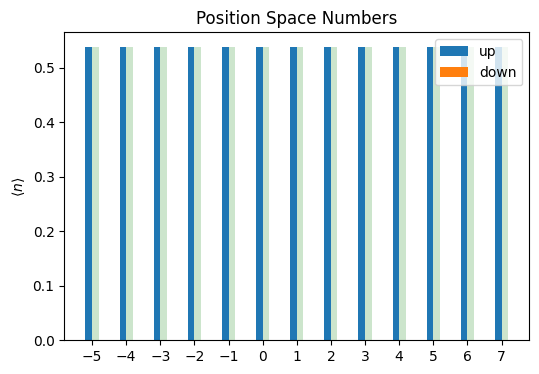

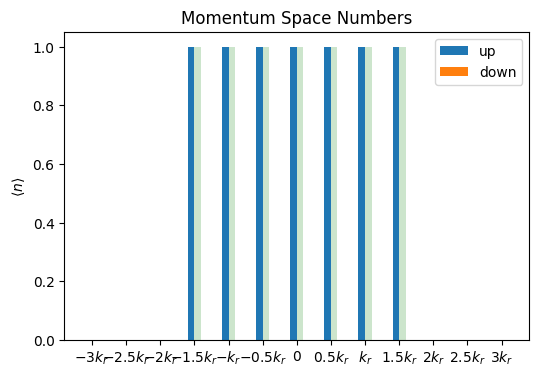

In [14]:
initial_position_nums_up, initial_position_nums_down = soc_system.position_expected_numbers(initial_state)
initial_momentum_nums_up, initial_momentum_nums_down = soc_system.momentum_expected_numbers(initial_state)

plot_numbers(initial_position_nums_up, initial_position_nums_down, title="Position Space Numbers")
plot_numbers(initial_momentum_nums_up, initial_momentum_nums_down, tick_labels=k_tick_labels, title="Momentum Space Numbers")

In [26]:
t0 = 0
t1 = 0.4 / 0.1129
n_timesteps = 11
n_fine_steps = 101
save_at = np.linspace(t0, t1, n_fine_steps)
step_size = save_at[1] - save_at[0]     

### SOC evolution

In [ ]:
csr_hamiltonian = soc_system.sparse_hamiltonian_scipy_csr()

In [24]:
psis = scipy.sparse.linalg.expm_multiply(
    -1j * csr_hamiltonian / hbar,
    initial_state,
    start=t0,
    stop=t1,
    num=n_fine_steps
)

spin_up_numbers, spin_down_numbers = soc_system.momentum_expected_numbers_vectorized(psis)

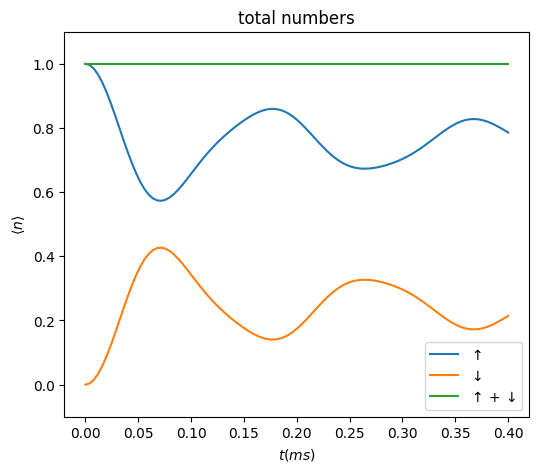

In [27]:
plt.figure(figsize=(6, 5))

# for i in range(8):
#     plt.plot(t, spin_up_numbers[:, i], label=f"$\\uparrow$, {i}")
#     plt.plot(t, spin_down_numbers[:, i], label=f"$\\downarrow$, {i}")

total_up = jnp.sum(spin_up_numbers, axis=1) / soc_system.n_particle
total_down = jnp.sum(spin_down_numbers, axis=1) / soc_system.n_particle

plt.title("total numbers")

plt.plot(save_at * 0.1129, total_up, label="$\\uparrow$")
plt.plot(save_at * 0.1129, total_down, label="$\\downarrow$")
plt.plot(save_at * 0.1129, total_up + total_down, label="$\\uparrow + \\downarrow$")

plt.ylabel("$\\langle n \\rangle$")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()

C:\Users\pco0511\AppData\Local\Temp\ipykernel_21804\1610106256.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


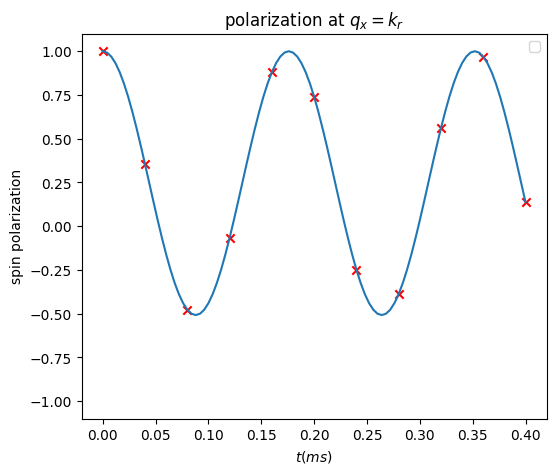

In [ ]:
plt.figure(figsize=(6, 5))

plt.title("polarization at $q_x = k_r$")

n_up = spin_up_numbers[:, 2]
n_down = spin_down_numbers[:, 2]
polarization = (n_up - n_down) / (n_up + n_down)

plt.plot(save_at * 0.1129, polarization)
plt.scatter(save_at[0::10] * 0.1129, polarization[0::10], marker='x', color='red')

plt.ylabel("spin polarization")
plt.xlabel("$t (ms)$")
plt.ylim(-1.1, 1.1)

plt.legend()
plt.show()

### Loss Fraction Simulation:

In [32]:
loss_time = 1.0 / 0.1129 # 1 ms

In [33]:
csr_loss_hamiltonian = pa_system.sparse_hamiltonian_scipy_csr()
initial_states = psis[0::10]

100%|██████████| 657800/657800 [19:50<00:00, 552.33it/s]


In [39]:
fractions = np.zeros((n_timesteps,))
for i in tqdm.trange(n_timesteps):
    initial_state = initial_states[i]
    
    numbers_up_i, numbers_down_i = soc_system.momentum_expected_numbers(initial_state)
    num_i = numbers_up_i[2] + numbers_down_i[2]
    
    state_after_pa = scipy.sparse.linalg.expm_multiply(-1j * csr_loss_hamiltonian * loss_time / hbar, initial_state)
    
    numbers_up_f, numbers_down_f = soc_system.momentum_expected_numbers(state_after_pa)
    num_f = numbers_up_f[2] + numbers_down_f[2]
    fractions[i] = num_f / num_i
    

  0%|          | 0/11 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(6, 5))

plt.title("loss fractions $q_x = k_r$")

plt.scatter(save_at[0::10] * 0.1129, fractions)

plt.ylabel("loss fraction")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()

## Plot & Save

In [36]:
exp_data_path1 = r"C:\workspace\yb-soc-two-body-loss\data\experiment\OneDrive_1_7-5-2025\unit_figure_4_b_upper.csv"
exp_data_path2 = r"C:\workspace\yb-soc-two-body-loss\data\experiment\OneDrive_1_7-5-2025\unit_figure_4_b_lower.csv"

In [40]:
df_upper = pd.read_csv(exp_data_path1)
exp_time = np.array(df_upper["time"]) * 1000 # s -> ms
exp_polarization = np.array(df_upper["mean"])

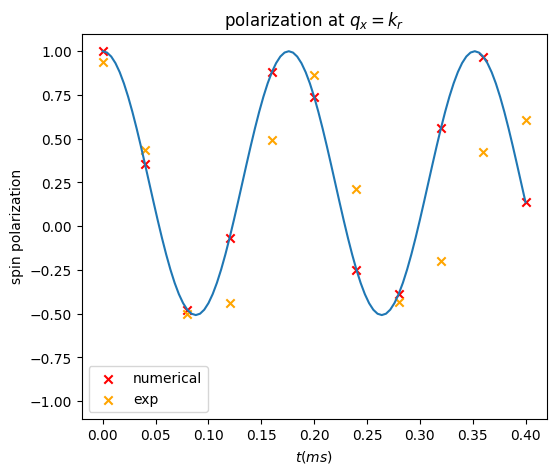

In [42]:
plt.figure(figsize=(6, 5))

plt.title("polarization at $q_x = k_r$")

n_up = spin_up_numbers[:, 2]
n_down = spin_down_numbers[:, 2]
polarization = (n_up - n_down) / (n_up + n_down)

plt.plot(save_at * 0.1129, polarization)
plt.scatter(save_at[0::10] * 0.1129, polarization[0::10], marker='x', color='red', label="numerical")
plt.scatter(exp_time[:11], exp_polarization[:11], marker='x', color='orange', label="exp")

plt.ylabel("spin polarization")
plt.xlabel("$t (ms)$")
plt.ylim(-1.1, 1.1)

plt.legend()
plt.show()

In [ ]:
df_lower = pd.read_csv(exp_data_path2)
exp_time = np.array(df_upper["time"]) * 1000 # s -> ms
exp_loss_fraction = np.array(df_upper["mean"])

In [ ]:
plt.figure(figsize=(6, 5))

plt.title("loss fractions $q_x = k_r$")

plt.scatter(save_at[0::10] * 0.1129, fractions, label="numerical")
plt.scatter(exp_time, fractions, label="exp")

plt.ylabel("loss fraction")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()